# PDDL Attack Path Evaluation
Evaluate generated PDDL attack paths: solvability, syntax, and semantic quality.

## 1. Environment Setup (imports, constnats, global variables)

In [ ]:
import sys
import os
import re
import json
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import re as _re

from cve2pddlap.core.data_loader import load_few_shot_pool
from cve2pddlap.evaluation import create_ff_checker, create_enhsp_checker
from cve2pddlap.evaluation.problem_pddl_generator import generate_problem
from cve2pddlap.llm_providers.remote.openai_compat import QwenProvider


import torch
from sentence_transformers import SentenceTransformer, util as st_util
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline as hf_pipeline

from sklearn.metrics import classification_report, precision_recall_curve
from sklearn.model_selection import GroupKFold

from openai import OpenAI

from jinja2 import Environment, FileSystemLoader


# Project root (relative — works from notebooks/attack_paths/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

# Data paths and file names
DATASET_PATH = os.path.join(PROJECT_ROOT, 'resources', 'data', 'CVE-PDDL-NNL-ReAP')
TARGET_POOL_FILE = os.path.join(PROJECT_ROOT, 'resources', 'data', 'target_pool.json')
GENERATED_DOMAIN_DIR = os.path.join(PROJECT_ROOT, 'generated_domain')
FIG_DIR = os.path.join(PROJECT_ROOT, 'Fig', 'embedding_intrinsic')
os.makedirs(FIG_DIR, exist_ok=True)
FIG_DIR_EXT = os.path.join(PROJECT_ROOT, 'Fig', 'embedding_extrinsic')
os.makedirs(FIG_DIR_EXT, exist_ok=True)
EVAL_SET_DIR = os.path.join(GENERATED_DOMAIN_DIR, 'eval_set')
PROMPTS_PATH = os.path.join(PROJECT_ROOT, 'resources', 'prompt', 'evaluation')
AP_PATTERN = re.compile(r'^AP\d+$')
DOMAIN_FILE = 'domain.pddl'
PROBLEM_FILE = 'problem.pddl'

# Models (small defaults — replace with preferred models)
# EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
EMBEDDING_MODEL_NAME = "BAAI/bge-base-en-v1.5"  # stronger general model with safetensors support

LLM_MODEL_NAME = "HuggingFaceTB/SmolLM2-1.7B-Instruct"

# Generation parameters
SEED = 42
TEMPERATURE = 0.0
TOP_K = 1


@dataclass(frozen=True)
class EvaluationFlags:
    syntax_check: bool = True
    embedding_intrinsic: bool = True
    embedding_extrinsic: bool = True
    llm_intrinsic: bool = True
    llm_extrinsic: bool = True


eval_flags = EvaluationFlags()

os.environ['MallocStackLogging'] = '0'

# Results output directory
RESULTS_BASE = os.path.join(PROJECT_ROOT, "results", "tests", "reference_set")
import time
import platform

def get_device_info():
    """Return device info dict."""
    import torch
    return {
        "platform": platform.platform(),
        "processor": platform.processor(),
        "python": platform.python_version(),
        "torch_device": "cuda" if torch.cuda.is_available() else "cpu",
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A",
    }
import matplotlib.pyplot as plt
from dotenv import load_dotenv


- Why `BAAI/bge-base-en-v1.5`?
  - Strong MTEB performance. On the [Massive Text Embedding Benchmark](https://huggingface.co/spaces/mteb/leaderboard), bge-base is among the top-performing models in its size class (approximately 110M parameters).
  - Cross-modal capability for code and natural language. The bge series performs well on tasks such as code search and code–natural language matching, making it suitable for measuring cross-modal similarity between natural-language CVE descriptions and PDDL code.

## 2. Load data, Prompts, LLM (tokenizer and embedding model)

In [63]:
few_shot_pool = load_few_shot_pool(DATASET_PATH)
print(f'Reference examples: {len(few_shot_pool)}')
for ex in few_shot_pool[:5]:
    print(f'  {ex.key}')
print('  ...')
print(f'Generated domain dir to be evaluated: {os.path.relpath(EVAL_SET_DIR)}')

Reference examples: 55
  CVE-2022-1471 / AP1
  CVE-2022-40149 / AP1
  CVE-2022-40149 / AP2
  CVE-2022-40150 / AP1
  CVE-2022-40150 / AP2
  ...
Generated domain dir to be evaluated: ../../generated_domain/eval_set


In [68]:
few_shot_pool = load_few_shot_pool(DATASET_PATH)
print(f'Reference examples: {len(few_shot_pool)}')
for ex in few_shot_pool[:5]:
    print(f'  {ex.key}')
print('  ...')
print(f'Generated domain dir to be evaluated: {os.path.relpath(EVAL_SET_DIR)}')


def load_target_pool(target_pool_file):
    """Load CVE descriptions from target_pool.json. Returns {cve_id: description}."""
    with open(target_pool_file, encoding='utf-8') as f:
        pool = json.load(f)
    return {entry['cve_id']: entry['description'] for entry in pool}


def load_dataset(data_path, cve_descriptions):
    """Load all CVEs with their descriptions (from target_pool) and attack path PDDL files."""
    dataset = []
    for cve_dir in sorted(Path(data_path).iterdir()):
        if not cve_dir.is_dir():
            continue
        cve_id = cve_dir.name
        description = cve_descriptions.get(cve_id)
        if description is None:
            continue
        attack_paths = []
        for ap_dir in sorted(cve_dir.iterdir()):
            if not ap_dir.is_dir() or not AP_PATTERN.match(ap_dir.name):
                continue
            domain_file = ap_dir / DOMAIN_FILE
            problem_file = ap_dir / PROBLEM_FILE
            if domain_file.exists() and problem_file.exists():
                attack_paths.append({
                    'ap_id': ap_dir.name,
                    'domain': domain_file.read_text(encoding='utf-8').strip(),
                    'problem': problem_file.read_text(encoding='utf-8').strip(),
                })
        dataset.append({
            'cve_id': cve_id,
            'description': description,
            'attack_paths': attack_paths,
        })
    return dataset


def load_prompts(prompts_path):
    """Load Jinja2 evaluation prompt templates."""
    return Environment(loader=FileSystemLoader(prompts_path))


def load_embedding_model(model_name):
    """Load a SentenceTransformer bi-encoder model."""
    return SentenceTransformer(model_name)


def load_llm(model_name):
    """Load a HuggingFace causal LLM with its tokenizer."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        dtype=torch.float16,
        device_map='auto',
    )
    gen = hf_pipeline(
        'text-generation',
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=512,
        do_sample=False,
    )
    return gen, tokenizer

TARGET_POOL_TI_FILE = os.path.join(PROJECT_ROOT, "resources", "data", "target_pool_ti.json")

def load_target_pool_ti(path):
    """Load TI-enriched target pool. Returns {cve_id: {field: value}}."""
    with open(path, encoding="utf-8") as f:
        pool = json.load(f)
    return {entry["cve_id"]: entry for entry in pool}

def strip_base_score(cvss_nl):
    """Remove Base Score from CVSS vector NL string."""
    if not cvss_nl:
        return ""
    return _re.sub(r"\s*Base Score:\s*[\d.]+\.?\s*", "", cvss_nl).strip()

def build_nl_ti_selected(entry_ti):
    """Build TI-selected NL: desc + capec + cvss_vector_nl (no base score)."""
    parts = [entry_ti.get("description", "")]
    capec = entry_ti.get("capec", "")
    if capec:
        parts.append(capec)
    cvss = strip_base_score(entry_ti.get("cvss_vector_nl", ""))
    if cvss:
        parts.append(cvss)
    return " ".join(parts)

cve_descriptions = load_target_pool(TARGET_POOL_FILE)
dataset = load_dataset(DATASET_PATH, cve_descriptions)
prompt_env = load_prompts(PROMPTS_PATH)

ti_pool = load_target_pool_ti(TARGET_POOL_TI_FILE)
print(f"TI pool loaded: {len(ti_pool)} CVEs")

embedding_model = None
if eval_flags.embedding_intrinsic or eval_flags.embedding_extrinsic:
    embedding_model = load_embedding_model(EMBEDDING_MODEL_NAME)

embedding_model = None
if eval_flags.embedding_intrinsic or eval_flags.embedding_extrinsic:
    embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

llm, tokenizer = None, None
if eval_flags.llm_intrinsic or eval_flags.llm_extrinsic:
    llm, tokenizer = load_llm(LLM_MODEL_NAME)

Reference examples: 55
  CVE-2022-1471 / AP1
  CVE-2022-40149 / AP1
  CVE-2022-40149 / AP2
  CVE-2022-40150 / AP1
  CVE-2022-40150 / AP2
  ...
Generated domain dir to be evaluated: ../../generated_domain/eval_set
TI pool loaded: 26 CVEs


Device set to use cpu


## 3. Evaluation

### 3.1 Syntax Check (ENHSP)

In [65]:
enhsp = create_enhsp_checker()

t_start_syntax = time.time()
reference_syntax_results = []
for entry in dataset:
    for ap in entry["attack_paths"]:
        problem_str = generate_problem(ap["domain"])
        r_enhsp = enhsp.check_from_string(ap["domain"], problem_str)
        result = {
            "cve_id": entry["cve_id"],
            "ap_id": ap["ap_id"],
            "syntax_ok": r_enhsp.success,
            "error": r_enhsp.error,
        }
        reference_syntax_results.append(result)
        print(f"{entry['cve_id']}/{ap['ap_id']}  syntax: {r_enhsp.success}")

t_syntax = time.time() - t_start_syntax
n_pass = sum(1 for r in reference_syntax_results if r["syntax_ok"])
print(f"\nSyntax: {n_pass}/{len(reference_syntax_results)} passed, time: {t_syntax:.2f}s")

# Save
save_dir = os.path.join(RESULTS_BASE, "syntax")
os.makedirs(save_dir, exist_ok=True)
with open(os.path.join(save_dir, "results.json"), "w") as f:
    json.dump(reference_syntax_results, f, indent=2)
with open(os.path.join(save_dir, "metadata.json"), "w") as f:
    json.dump({"time_seconds": t_syntax, "n_domains": len(reference_syntax_results),
               "tool": "ENHSP", "device_info": get_device_info()}, f, indent=2)
print(f"Saved to {save_dir}")


Python(36378) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


CVE-2022-1471/AP1  syntax: True


Python(36383) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


CVE-2022-40149/AP1  syntax: True


Python(36417) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


...

CVE-2023-44487/AP1  syntax: True


Python(36621) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


CVE-2023-46589/AP1  syntax: True


Python(36683) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


KeyboardInterrupt: 

### 3.2 Solvability (Metric-FF)

In [66]:
ff = create_ff_checker()

t_start_solv = time.time()
reference_solvability_results = []
for entry in dataset:
    for ap in entry["attack_paths"]:
        problem_str = generate_problem(ap["domain"])
        r_ff = ff.check_from_string(ap["domain"], problem_str)
        result = {
            "cve_id": entry["cve_id"],
            "ap_id": ap["ap_id"],
            "solvable": r_ff.solvable,
            "plan_length": r_ff.plan_length,
            "plan": r_ff.plan,
            "error": r_ff.error,
        }
        reference_solvability_results.append(result)
        status = "SOLVABLE" if r_ff.solvable else "FAIL"
        print(f"{entry['cve_id']}/{ap['ap_id']}  {status}  plan_length={r_ff.plan_length}")
        if r_ff.plan:
            for i, action in enumerate(r_ff.plan):
                print(f"  {i}: {action}")

t_solv = time.time() - t_start_solv
n_solvable = sum(1 for r in reference_solvability_results if r["solvable"])
print(f"\nSolvability: {n_solvable}/{len(reference_solvability_results)} solvable, time: {t_solv:.2f}s")

# Save
save_dir = os.path.join(RESULTS_BASE, "solvability")
os.makedirs(save_dir, exist_ok=True)
with open(os.path.join(save_dir, "results.json"), "w") as f:
    json.dump(reference_solvability_results, f, indent=2)
with open(os.path.join(save_dir, "metadata.json"), "w") as f:
    json.dump({"time_seconds": t_solv, "n_domains": len(reference_solvability_results),
               "tool": "Metric-FF", "device_info": get_device_info()}, f, indent=2)
print(f"Saved to {save_dir}")


Python(37104) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37105) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37106) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37107) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


CVE-2022-1471/AP1  SOLVABLE  plan_length=10
  0: ATTACKER-CRAFTS-MALICIOUS-JAVA-CLASS SEFA JAVA-GADGET-CLASS_SEFA COMMAND-EXECUTION-LOGIC_SEFA CVE_2022_1471
  1: ATTACKER-CRAFTS-MALICIOUS-YAML-PAYLOAD SEFA YAML-PAYLOAD_SEFA JAVA-GADGET-CLASS_SEFA JNDI-ENDPOINT_SEFA JAVA-GADGET-CLASS_SEFA CVE_2022_1471
  2: ATTACKER-SENDS-MALICIOUS-YAML-VIA-HTTP-POST HTTP-POST-REQUEST_SEFA SEFA YAML-PAYLOAD_SEFA YAML-ENDPOINT_SEFA CVE_2022_1471
  3: TARGET-SYSTEM-RECEIVES-HTTP-POST-REQUEST-WITH-MALICIOUS-PAYLOAD SEFA HTTP-POST-REQUEST_SEFA YAML-PAYLOAD_SEFA YAML-ENDPOINT_SEFA
  4: TARGET-SYSTEM-PASSES-YAML-TO-SNAKEYAML-LOADER HTTP-POST-REQUEST_SEFA YAML-PAYLOAD_SEFA SEFA SNAKEYAML-LIBRARY_SEFA
  5: TARGET-SYSTEM-STARTS-YAML-DESERIALIZATION-WITH-CONSTRUCTOR YAML-PAYLOAD_SEFA SNAKEYAML-LIBRARY_SEFA YAML-CONSTRUCTOR_SEFA SEFA
  6: TARGET-SYSTEM-INSTANTIATES-DANGEROUS-JAVA-GADGET-CLASS SEFA YAML-CONSTRUCTOR_SEFA JAVA-GADGET-CLASS_SEFA YAML-PAYLOAD_SEFA
  7: TARGET-SYSTEM-LOADS-MALICIOUS-CLASS-FROM-JNDI-ENDP

Python(37108) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37109) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37110) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37111) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


CVE-2022-40150/AP2  SOLVABLE  plan_length=9
  0: ATTACKER-CRAFTS-MALICIOUS-XML-PAYLOAD SEFA XML-PAYLOAD_SEFA JAVA-LIBRARY_SEFA CVE_2022_40150
  1: ATTACKER-SENDS-HTTP-POST-REQUEST-WITH-MALICIOUS-PAYLOAD SEFA HTTP-POST-REQUEST_SEFA XML-PAYLOAD_SEFA SOAP-ENDPOINT_SEFA CVE_2022_40150
  2: TARGET-SYSTEM-RECEIVES-HTTP-POST-REQUEST-WITH-MALICIOUS-PAYLOAD SEFA HTTP-POST-REQUEST_SEFA XML-PAYLOAD_SEFA SOAP-ENDPOINT_SEFA
  3: TARGET-SYSTEM-EXTRACTS-XML-PAYLOAD-FROM-HTTP-REQUEST SEFA HTTP-POST-REQUEST_SEFA XML-PAYLOAD_SEFA SOAP-ENDPOINT_SEFA
  4: TARGET-SYSTEM-INVOKES-JETTISON-XML-TO-JSON-TRANSFORMATION SEFA JAVA-LIBRARY_SEFA XML-PAYLOAD_SEFA JSON-PAYLOAD_SEFA
  5: TARGET-SYSTEM-USES-JETTISON-JSON-PARSER SEFA JAVA-LIBRARY_SEFA JSON-PAYLOAD_SEFA
  6: TARGET-SYSTEM-JETTISON-PARSER-ALLOCATES-HEAP-MEMORY-FOR-JSON-CONSTRUCTION JAVA-LIBRARY_SEFA JSON-PAYLOAD_SEFA SEFA
  7: TARGET-SYSTEM-TRIGGERS-OUTOFMEMORY-ERROR SEFA CVE_2022_40150
  8: TARGET-SYSTEM-BECOMES-UNRESPONSIVE SEFA
CVE-2023-2976/AP1  SOLVAB

Python(37112) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37113) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37114) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37115) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


...

Python(37148) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37149) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37150) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37151) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37152) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


CVE-2024-47072/AP1  SOLVABLE  plan_length=8
  0: ATTACKER-CRAFTS-MALICIOUS-BINARY-XSTREAM-PAYLOAD SEFA BINARY-PAYLOAD_SEFA JAVA-LIBRARY_SEFA CVE_2024_47072
  1: ATTACKER-SENDS-HTTP-POST-REQUEST-WITH-BINARY-PAYLOAD SEFA HTTP-POST-REQUEST_SEFA BINARY-PAYLOAD_SEFA API-ENDPOINT_SEFA CVE_2024_47072
  2: TARGET-SYSTEM-RECEIVES-HTTP-POST-REQUEST-WITH-MALICIOUS-PAYLOAD SEFA HTTP-POST-REQUEST_SEFA BINARY-PAYLOAD_SEFA API-ENDPOINT_SEFA
  3: TARGET-SYSTEM-EXTRACTS-BINARY-PAYLOAD-FROM-HTTP-REQUEST SEFA HTTP-POST-REQUEST_SEFA BINARY-PAYLOAD_SEFA API-ENDPOINT_SEFA
  4: TARGET-SYSTEM-USES-XSTREAM-BINARY-DRIVER SEFA JAVA-LIBRARY_SEFA BINARY-STREAM-DRIVER_SEFA BINARY-PAYLOAD_SEFA
  5: TARGET-SYSTEM-BINARY-DRIVER-ALLOCATES-STACK-FRAMES-FOR-RECURSIVE-DECODING JAVA-LIBRARY_SEFA BINARY-STREAM-DRIVER_SEFA BINARY-PAYLOAD_SEFA SEFA
  6: TARGET-SYSTEM-TRIGGERS-STACKOVERFLOW-ERROR SEFA CVE_2024_47072
  7: TARGET-SYSTEM-BECOMES-UNRESPONSIVE SEFA
CVE-2025-22228/AP1  SOLVABLE  plan_length=9
  0: TARGET-SYSTEM-EXPO

Python(37153) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37154) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37155) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37156) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(37157) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


CVE-2025-24813/AP2  SOLVABLE  plan_length=9
  0: ATTACKER-CREATES-MALICIOUS-CONTENT-FOR-INJECTION SEFA MALICIOUS-CONTENT_SEFA SENSITIVE-FILE_SEFA CVE_2025_24813
  1: ATTACKER-CRAFTS-HTTP-PUT-REQUEST-WITH-INTERNAL-DOT-PATH-MANIPULATION HTTP-PUT-REQUEST_SEFA SENSITIVE-FILE_SEFA PUBLIC-DIRECTORY_SEFA SENSITIVE-DIRECTORY_SEFA SEFA CVE_2025_24813 MALICIOUS-CONTENT_SEFA
  2: ATTACKER-INCLUDES-CONTENT-RANGE-HEADERS-FOR-PARTIAL-PUT HTTP-PUT-REQUEST_SEFA CONTENT-RANGE-HEADERS_SEFA SEFA CVE_2025_24813
  3: ATTACKER-SENDS-MALICIOUS-PARTIAL-HTTP-PUT-REQUEST-TO-TOMCAT HTTP-PUT-REQUEST_SEFA CONTENT-RANGE-HEADERS_SEFA SEFA TOMCAT_SEFA MALICIOUS-CONTENT_SEFA CVE_2025_24813
  4: TARGET-SYSTEM-RECEIVES-HTTP-PUT-REQUEST HTTP-PUT-REQUEST_SEFA SEFA
  5: TARGET-SYSTEM-TOMCAT-DEFAULT-SERVLET-PROCESSES-REQUEST-WITHOUT-PROPER-VALIDATION HTTP-PUT-REQUEST_SEFA SEFA DEFAULT-SERVLET_SEFA TOMCAT_SEFA
  6: TARGET-SYSTEM-TOMCAT-DEFAULT-SERVLET-INCORRECTLY-NORMALIZES-PATH HTTP-PUT-REQUEST_SEFA DEFAULT-SERVLET_SEFA TOM

Python(37158) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


### 3.3 Semantic Evaluation

#### 3.3.1 Intrinsic

##### 3.3.1.1a Embedding: NL CVE Description vs PDDL Similarity

Block 1:  the function to compute the embedding similarity between the NL CVE description vs the PDDL code (domain)

In [69]:
def embedding_similarity_intrinsic(descriptions, pddl_texts, model):
    """Cosine similarity matrix between NL descriptions and PDDL codes.
    Args:
        descriptions: list of CVE NL description strings
        pddl_texts: list of PDDL (domain) strings
        model: SentenceTransformer model
    Returns:
        numpy array of shape (len(descriptions), len(pddl_texts))
    """
    E_desc = model.encode(
        descriptions,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    E_pddl = model.encode(
        pddl_texts,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    S = E_desc @ E_pddl.T
    return S.float().cpu().numpy()

Block 2: call the function with the code and the specifications from the data set

In [70]:
# descriptions = []
# pddl_texts = []
# labels = []

# eval_set_path = Path(EVAL_SET_DIR)
# for cve_dir in sorted(eval_set_path.iterdir()):
#     if not cve_dir.is_dir():
#         continue
#     cve_id = cve_dir.name
#     description = cve_descriptions.get(cve_id)
#     if description is None:
#         print(f"SKIP {cve_id}: no description in target_pool.json")
#         continue
#     for config_dir in sorted(cve_dir.iterdir()):
#         if not config_dir.is_dir():
#             continue
#         domain_file = config_dir / DOMAIN_FILE
#         if not domain_file.exists():
#             continue
#         domain = domain_file.read_text(encoding='utf-8').strip()
#         problem = problem_file.read_text(encoding='utf-8').strip() if problem_file.exists() else ''
#         descriptions.append(description)
#         pddl_texts.append(domain)
#         labels.append(f"{cve_id}/{config_dir.name}")

# sim_matrix = embedding_similarity_intrinsic(descriptions, pddl_texts, embedding_model)
# emb_intrinsic_results = []
# for i, label in enumerate(labels):
#     sim = float(sim_matrix[i, i])
#     emb_intrinsic_results.append({'label': label, 'similarity': sim})
#     print(f"{label}  similarity: {sim:.4f}")

t_start_emb_intr = time.time()
# ── Intrinsic embedding on reference data ──
descriptions = []
pddl_texts = []
labels = []

for entry in dataset:
    for ap in entry["attack_paths"]:
        descriptions.append(entry["description"])
        pddl_texts.append(ap["domain"])
        labels.append(f"{entry['cve_id']}/{ap['ap_id']}")

sim_matrix = embedding_similarity_intrinsic(descriptions, pddl_texts, embedding_model)
emb_intrinsic_results = []
for i, label in enumerate(labels):
    sim = float(sim_matrix[i, i])
    emb_intrinsic_results.append({"label": label, "similarity": sim})
    print(f"{label}  similarity: {sim:.4f}")


t_start_emb_intr = time.time()
# ── Intrinsic embedding on reference data ──
descriptions = []
pddl_texts = []
labels = []

for entry in dataset:
    for ap in entry["attack_paths"]:
        descriptions.append(entry["description"])
        pddl_texts.append(ap["domain"])
        labels.append(f"{entry['cve_id']}/{ap['ap_id']}")

sim_matrix = embedding_similarity_intrinsic(descriptions, pddl_texts, embedding_model)
emb_intrinsic_results = []
for i, label in enumerate(labels):
    sim = float(sim_matrix[i, i])
    emb_intrinsic_results.append({"label": label, "similarity": sim})
    print(f"{label}  similarity: {sim:.4f}")

t_elapsed_emb_intr = time.time() - t_start_emb_intr

save_dir = os.path.join(RESULTS_BASE, "semantic", "intrinsic", "similarity")
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, f"results_{EMBEDDING_MODEL_NAME.replace('/', '_')}.json"), "w") as f:
    json.dump({"model": EMBEDDING_MODEL_NAME, "results": emb_intrinsic_results}, f, indent=2)

with open(os.path.join(save_dir, f"metadata_{EMBEDDING_MODEL_NAME.replace('/', '_')}.json"), "w") as f:
    json.dump({
        "time_seconds": t_elapsed_emb_intr,
        "model": EMBEDDING_MODEL_NAME,
        "n_domains": len(emb_intrinsic_results),
        "device_info": get_device_info(),
    }, f, indent=2)

print(f"\nSaved to {save_dir}")
print(f"Time: {t_elapsed_emb_intr:.2f}s")


CVE-2022-1471/AP1  similarity: 0.7166
CVE-2022-40149/AP1  similarity: 0.6377
CVE-2022-40149/AP2  similarity: 0.6377
CVE-2022-40150/AP1  similarity: 0.6427
CVE-2022-40150/AP2  similarity: 0.6427
CVE-2023-2976/AP1  similarity: 0.6283
CVE-2023-2976/AP2  similarity: 0.6212
CVE-2023-2976/AP3  similarity: 0.6188
CVE-2023-33202/AP1  similarity: 0.6814
CVE-2023-33202/AP2  similarity: 0.6898
CVE-2023-33202/AP3  similarity: 0.6784
CVE-2023-34055/AP1  similarity: 0.6425
CVE-2023-44487/AP1  similarity: 0.5699
CVE-2023-46589/AP1  similarity: 0.6703
CVE-2023-46589/AP2  similarity: 0.6694
CVE-2023-46589/AP3  similarity: 0.6703
CVE-2023-46589/AP4  similarity: 0.6694
CVE-2023-6378/AP1  similarity: 0.6589
CVE-2024-12798/AP1  similarity: 0.7491
CVE-2024-12798/AP2  similarity: 0.7432
CVE-2024-12798/AP3  similarity: 0.7460
CVE-2024-12798/AP4  similarity: 0.7489
CVE-2024-12798/AP5  similarity: 0.7489
CVE-2024-12798/AP6  similarity: 0.7494
CVE-2024-12798/AP7  similarity: 0.7495
CVE-2024-22243/AP1  similarity

Block 3: Use bootstrapping to find the best threshold for the intrinsic semantic similarity.

In [71]:
def bootstrap_threshold(scores, n_bootstrap=10000, ci_alpha=0.05, seed=42):
    """Bootstrap the mean similarity to derive a threshold.
    Returns:
        ci_low: lower bound of (1 - ci_alpha) CI of bootstrapped means
        ci_high: upper bound
        boot_means: array of bootstrapped means
    """
    rng = np.random.default_rng(seed)
    n = len(scores)
    boot_means = np.array([
        rng.choice(scores, size=n, replace=True).mean()
        for _ in range(n_bootstrap)
    ])
    ci_low = np.percentile(boot_means, 100 * ci_alpha / 2)
    ci_high = np.percentile(boot_means, 100 * (1 - ci_alpha / 2))
    return ci_low, ci_high, boot_means


def collect_reference_scores_intrinsic(dataset, model):
    """Compute cosine similarities for all reference (description, domain) pairs."""
    descriptions = []
    pddl_texts = []
    for entry in dataset:
        for ap in entry['attack_paths']:
            descriptions.append(entry['description'])
            pddl_texts.append(ap['domain'])
    E_desc = model.encode(descriptions, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    E_pddl = model.encode(pddl_texts, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    scores = (E_desc * E_pddl).sum(dim=1).float().cpu().numpy()
    return scores


scores_intrinsic = collect_reference_scores_intrinsic(dataset, embedding_model)
ci_low_i, ci_high_i, boot_means_i = bootstrap_threshold(scores_intrinsic, seed=SEED)

print(f"Intrinsic threshold (model={EMBEDDING_MODEL_NAME}, n={len(scores_intrinsic)})")
print(f"  mean={scores_intrinsic.mean():.4f}  std={scores_intrinsic.std():.4f}  "
      f"min={scores_intrinsic.min():.4f}  max={scores_intrinsic.max():.4f}")
print(f"  95% CI of mean: [{ci_low_i:.4f}, {ci_high_i:.4f}]")
print(f"  Suggested threshold (CI lower bound): {ci_low_i:.4f}")

Intrinsic threshold (model=BAAI/bge-base-en-v1.5, n=55)
  mean=0.6954  std=0.0472  min=0.5699  max=0.7602
  95% CI of mean: [0.6824, 0.7077]
  Suggested threshold (CI lower bound): 0.6824


Block 4: Cross-validation, performance estimation, and corrected proportion

Process:
1. Build positive/negative pairs from reference data 
   - 1:PDDL doman vs same CVE NL desc 
   - 0: PDDL doman vs different CVE NL desc
2. CVE-level GroupKFold CV with bootstrap threshold on each train fold
3. Out-of-fold predictions → global confusion matrix → TPR, FPR, classification report
4. Apply calibrated threshold to generated domains → corrected proportion π = (PPV - FPR) / (TPR - FPR)

Why GroupKFold?
- one CVE NL desc corresponded to multiple PDDL AP domain 
- If the train fold contains (for example, CVE-2024-12798 NL desc vs domain_AP4) and the validation fold contains (CVE-2024-12798 NL desc vs domain_AP1), the threshold is calibrated on an embedding the validation set also shares, this is data leakage. GroupKFold ensures all pairs involving the same CVE NL desc are assigned to the same fold, eliminating this issue.

In [72]:
# Step 1: Build positive/negative pairs

def build_intrinsic_pairs(dataset, model):
    """
    Build (scores, labels, groups) for intrinsic embedding evaluation.
    Positive (1): CVE domain vs same CVE NL description
    Negative (0): CVE domain vs different CVE NL description
    Groups: assigned by the description-side CVE
    Reuses embedding_similarity_intrinsic for batch computation.
    """
    descs, domains, cve_ids = [], [], []
    for entry in dataset:
        for ap in entry["attack_paths"]:
            descs.append(entry["description"])
            domains.append(ap["domain"])
            cve_ids.append(entry["cve_id"])

    sim_matrix = embedding_similarity_intrinsic(descs, domains, model)

    scores, labels, groups = [], [], []
    n = len(descs)
    for i in range(n):
        for j in range(n):
            scores.append(float(sim_matrix[i, j]))
            labels.append(1 if cve_ids[i] == cve_ids[j] else 0)
            groups.append(cve_ids[i])

    return np.array(scores), np.array(labels), np.array(groups)


pair_scores_a, pair_labels_a, pair_groups_a = build_intrinsic_pairs(dataset, embedding_model)
print(f"Embedding Model: {EMBEDDING_MODEL_NAME}")
print(f"  Positive pairs: {pair_labels_a.sum()}, Negative pairs: {(pair_labels_a == 0).sum()}")
print(f"  Groups (CVEs): {len(np.unique(pair_groups_a))}")

# Global list for cross-model comparison CSV
calibration_embedding_rows = []


Embedding Model: BAAI/bge-base-en-v1.5
  Positive pairs: 203, Negative pairs: 2822
  Groups (CVEs): 21


In [73]:
# Step 2: CV calibration
def _find_threshold_pr(y_true, y_score):
    """Return the threshold closest to (1,1) in the precision-recall curve."""
    prec, rec, thr = precision_recall_curve(y_true, y_score)
    distances = np.sqrt((1 - prec[1:]) ** 2 + (1 - rec[1:]) ** 2)
    return float(thr[np.argmin(distances)])

def run_calibration(scores, labels, groups, k=5, n_bootstrap=500, random_state=42):
    """
    CVE-level GroupKFold CV with bootstrap threshold search on each train fold.
    Returns: median_threshold, fold_thresholds, y_pred (OOF), y_true (OOF)
    """
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels, dtype=int)
    groups = np.asarray(groups)
    rng = np.random.RandomState(random_state)

    unique_groups = np.unique(groups)
    n_groups = len(unique_groups)
    actual_k = min(k, n_groups)
    if actual_k < k:
        print(f"Warning: only {n_groups} groups, reducing k from {k} to {actual_k}")

    gkf = GroupKFold(n_splits=actual_k)
    fold_thresholds, y_pred_parts, y_true_parts = [], [], []

    for fold_i, (train_idx, val_idx) in enumerate(gkf.split(scores, labels, groups)):
        tr_scores, tr_labels = scores[train_idx], labels[train_idx]
        bt = []
        for _ in range(n_bootstrap):
            idx = rng.choice(len(tr_scores), size=len(tr_scores), replace=True)
            bt.append(_find_threshold_pr(tr_labels[idx], tr_scores[idx]))
        fold_thr = float(np.median(bt))
        fold_thresholds.append(fold_thr)
        y_pred_parts.append((scores[val_idx] >= fold_thr).astype(int))
        y_true_parts.append(labels[val_idx])
        val_groups = np.unique(groups[val_idx])
        print(f"  Fold {fold_i+1}: threshold={fold_thr:.4f}, val CVEs={list(val_groups)}")

    return (
        float(np.median(fold_thresholds)),
        fold_thresholds,
        np.concatenate(y_pred_parts),
        np.concatenate(y_true_parts),
    )


cv_threshold_a, cv_fold_thr_a, cv_pred_a, cv_true_a = run_calibration(
    pair_scores_a, pair_labels_a, pair_groups_a)
print("Fold thresholds:", [f"{t:.4f}" for t in cv_fold_thr_a])
print(f"Median threshold: {cv_threshold_a:.4f}")


  Fold 1: threshold=0.6850, val CVEs=['CVE-2023-44487', 'CVE-2024-12798', 'CVE-2024-34447', 'CVE-2024-38809']
  Fold 2: threshold=0.7337, val CVEs=['CVE-2023-33202', 'CVE-2023-34055', 'CVE-2024-22243', 'CVE-2024-38816']
  Fold 3: threshold=0.7105, val CVEs=['CVE-2022-40150', 'CVE-2024-22262', 'CVE-2024-38820', 'CVE-2025-22228']
  Fold 4: threshold=0.7337, val CVEs=['CVE-2022-40149', 'CVE-2024-22259', 'CVE-2024-47072', 'CVE-2025-24813']
  Fold 5: threshold=0.7337, val CVEs=['CVE-2022-1471', 'CVE-2023-2976', 'CVE-2023-46589', 'CVE-2023-6378', 'CVE-2024-38286']
Fold thresholds: ['0.6850', '0.7337', '0.7105', '0.7337', '0.7337']
Median threshold: 0.7337


In [75]:
# Step 3: Performance report

def report_row(y_true, y_pred, **meta):
    """Return a flat dict with classification metrics + TPR/FPR."""
    rpt = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    row = dict(meta)
    for key, val in rpt.items():
        if isinstance(val, dict):
            for metric, v in val.items():
                row[f"{key}__{metric}"] = v
        else:
            row[key] = val
    row["tpr"] = rpt.get("1", {}).get("recall", float("nan"))
    row["fpr"] = 1.0 - rpt.get("0", {}).get("recall", float("nan"))
    return row


print(f"Embedding Model ({EMBEDDING_MODEL_NAME})")
print(classification_report(cv_true_a, cv_pred_a, zero_division=0))

row_a = report_row(cv_true_a, cv_pred_a,
                   metric="embedding", model=EMBEDDING_MODEL_NAME,
                   mode="intrinsic", threshold=cv_threshold_a)
print(f"TPR = {row_a['tpr']:.4f}  FPR = {row_a['fpr']:.4f}")


Embedding Model (BAAI/bge-base-en-v1.5)
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      2822
           1       0.41      0.46      0.44       203

    accuracy                           0.92      3025
   macro avg       0.69      0.71      0.70      3025
weighted avg       0.92      0.92      0.92      3025

TPR = 0.4631  FPR = 0.0478


In [76]:
# Step 4: Apply threshold to reference domains + corrected proportion π 

def apply_threshold_batch(descriptions, domains, labels_list, model, threshold):
    """Apply threshold using batch embedding_similarity_intrinsic. Returns results and PPV."""
    sim_matrix = embedding_similarity_intrinsic(descriptions, domains, model)
    results = []
    for i, label in enumerate(labels_list):
        sim = float(sim_matrix[i, i])
        pred = 1 if sim >= threshold else 0
        results.append({"label": label, "similarity": sim, "prediction": pred})
        print(f"  {label:45s} prediction: {pred} (similarity: {sim:.4f})")
    predictions = [r["prediction"] for r in results]
    ppv = sum(predictions) / len(predictions) if predictions else 0
    return results, ppv


def corrected_proportion(ppv, tpr, fpr):
    """Corrected estimate of true positive proportion: pi = (PPV - FPR) / (TPR - FPR)"""
    denom = tpr - fpr
    if abs(denom) < 1e-10:
        return float("nan")
    return (ppv - fpr) / denom


# ── Apply to reference domains ──
ref_descs, ref_domains, ref_labels = [], [], []
for entry in dataset:
    for ap in entry["attack_paths"]:
        ref_descs.append(entry["description"])
        ref_domains.append(ap["domain"])
        ref_labels.append(f"{entry['cve_id']}/{ap['ap_id']}")

print(f"Applying threshold {cv_threshold_a:.4f} ({EMBEDDING_MODEL_NAME}) to reference domains:")
ref_results_a, ref_ppv_a = apply_threshold_batch(ref_descs, ref_domains, ref_labels, embedding_model, cv_threshold_a)
print(f"  Reference PPV: {ref_ppv_a:.4f} ({sum(r['prediction'] for r in ref_results_a)}/{len(ref_results_a)} predicted positive)")

# # ── Apply to generated domains (eval_set) — uncomment when ready ──
# gen_descs, gen_domains, gen_labels = [], [], []
# cve_descriptions = {entry["cve_id"]: entry["description"] for entry in dataset}
# eval_set_path = Path(EVAL_SET_DIR)
# for cve_dir in sorted(eval_set_path.iterdir()):
#     if not cve_dir.is_dir():
#         continue
#     cve_id = cve_dir.name
#     description = cve_descriptions.get(cve_id)
#     if description is None:
#         continue
#     for config_dir in sorted(cve_dir.iterdir()):
#         if not config_dir.is_dir():
#             continue
#         domain_file = config_dir / DOMAIN_FILE
#         if not domain_file.exists():
#             continue
#         gen_descs.append(description)
#         gen_domains.append(domain_file.read_text(encoding="utf-8").strip())
#         gen_labels.append(f"{cve_id}/{config_dir.name}")
#
# print(f"\nApplying threshold {cv_threshold_a:.4f} ({EMBEDDING_MODEL_NAME}) to generated domains:")
# gen_results_a, ppv_a = apply_threshold_batch(gen_descs, gen_domains, gen_labels, embedding_model, cv_threshold_a)
#
# pi_a = corrected_proportion(ppv_a, row_a["tpr"], row_a["fpr"])
# print(f"\n--- Corrected Proportion ---")
# print(f"PPV (raw positive rate on generated): {ppv_a:.4f}")
# print(f"TPR (from CV): {row_a['tpr']:.4f}")
# print(f"FPR (from CV): {row_a['fpr']:.4f}")
# print(f"pi (corrected proportion): {pi_a:.4f}")

# ── Save (reference only for now) ──
save_data = {
    "metric": "embedding",
    "model": EMBEDDING_MODEL_NAME,
    "mode": "intrinsic",
    "median_threshold": cv_threshold_a,
    "fold_thresholds": cv_fold_thr_a,
    "tpr": row_a["tpr"],
    "fpr": row_a["fpr"],
    "classification_report": classification_report(cv_true_a, cv_pred_a, output_dict=True, zero_division=0),
    "n_positive_pairs": int(pair_labels_a.sum()),
    "n_negative_pairs": int((pair_labels_a == 0).sum()),
    "n_groups": int(len(np.unique(pair_groups_a))),
    "ref_ppv": ref_ppv_a,
    "reference_predictions": ref_results_a,
}
save_path = Path(EVAL_SET_DIR) / f"cv_calibration_{EMBEDDING_MODEL_NAME.replace('/', '_')}.json"
save_path.write_text(json.dumps(save_data, indent=2), encoding="utf-8")
print(f"\nSaved: {save_path}")

# Append to global calibration rows
calibration_embedding_rows.append({
    "model": EMBEDDING_MODEL_NAME,
    "mode": "intrinsic",
    "threshold": cv_threshold_a,
    "tpr": row_a["tpr"],
    "fpr": row_a["fpr"],
    "1__precision": row_a.get("1__precision", float("nan")),
    "1__recall": row_a.get("1__recall", float("nan")),
    "1__f1-score": row_a.get("1__f1-score", float("nan")),
    "accuracy": row_a.get("accuracy", float("nan")),
    "ref_ppv": ref_ppv_a,
    "n_positive": int(pair_labels_a.sum()),
    "n_negative": int((pair_labels_a == 0).sum()),
})


Applying threshold 0.7337 (BAAI/bge-base-en-v1.5) to reference domains:
  CVE-2022-1471/AP1                             prediction: 0 (similarity: 0.7166)
  CVE-2022-40149/AP1                            prediction: 0 (similarity: 0.6377)
  CVE-2022-40149/AP2                            prediction: 0 (similarity: 0.6377)
  CVE-2022-40150/AP1                            prediction: 0 (similarity: 0.6427)
  CVE-2022-40150/AP2                            prediction: 0 (similarity: 0.6427)
  CVE-2023-2976/AP1                             prediction: 0 (similarity: 0.6283)
  CVE-2023-2976/AP2                             prediction: 0 (similarity: 0.6212)
  CVE-2023-2976/AP3                             prediction: 0 (similarity: 0.6188)
  CVE-2023-33202/AP1                            prediction: 0 (similarity: 0.6814)
  CVE-2023-33202/AP2                            prediction: 0 (similarity: 0.6898)
  CVE-2023-33202/AP3                            prediction: 0 (similarity: 0.6784)
  CVE-2023-3405

##### 3.3.1.1e Embedding Model B (bge-base): TI-Selected NL vs Action Names

Use `BAAI/bge-base-en-v1.5` with **TI-selected NL** (description + CAPEC + CVSS vector) on the NL side, and **extracted action names only** (no preconditions/effects) on the PDDL side.

In [32]:
# --- 3.3.1.1e: TI-selected NL vs action names only (bge-base) ---

# # ── eval_set (uncomment when ready) ──
# descriptions_e = []
# action_name_texts_e = []
# labels_e = []
# eval_set_path = Path(EVAL_SET_DIR)
# for cve_dir in sorted(eval_set_path.iterdir()):
#     if not cve_dir.is_dir():
#         continue
#     cve_id = cve_dir.name
#     ti_entry = ti_pool.get(cve_id)
#     if ti_entry is None:
#         continue
#     nl_ti = build_nl_ti_selected(ti_entry)
#     for config_dir in sorted(cve_dir.iterdir()):
#         if not config_dir.is_dir():
#             continue
#         domain_file = config_dir / DOMAIN_FILE
#         if not domain_file.exists():
#             continue
#         domain = domain_file.read_text(encoding="utf-8").strip()
#         action_names = re.findall(r"\(:action\s+([\w-]+)", domain)
#         descriptions_e.append(nl_ti)
#         action_name_texts_e.append(" ".join(action_names))
#         labels_e.append(f"{cve_id}/{config_dir.name}")

# ── 3.3.1.1e on reference data ──
descriptions_e = []
action_name_texts_e = []
labels_e = []

for entry in dataset:
    ti_entry = ti_pool.get(entry["cve_id"])
    if ti_entry is None:
        continue
    nl_ti = build_nl_ti_selected(ti_entry)
    for ap in entry["attack_paths"]:
        action_names = re.findall(r"\(:action\s+([\w-]+)", ap["domain"])
        descriptions_e.append(nl_ti)
        action_name_texts_e.append(" ".join(action_names))
        labels_e.append(f"{entry['cve_id']}/{ap['ap_id']}")


In [31]:
sim_matrix_e = embedding_similarity_intrinsic(descriptions_e, action_name_texts_e, embedding_model)
emb_intrinsic_results_e = []
for i, label in enumerate(labels_e):
    sim = float(sim_matrix_e[i, i])
    emb_intrinsic_results_e.append({"label": label, "similarity": sim})
    print(f"[3.3.1.1e] {label}  similarity: {sim:.4f}")

[3.2.1.1e] CVE-2022-1471/AP1  similarity: 0.7295
[3.2.1.1e] CVE-2022-40149/AP1  similarity: 0.7535
[3.2.1.1e] CVE-2022-40149/AP2  similarity: 0.7543
[3.2.1.1e] CVE-2022-40150/AP1  similarity: 0.7536
[3.2.1.1e] CVE-2022-40150/AP2  similarity: 0.7566
[3.2.1.1e] CVE-2023-2976/AP1  similarity: 0.7506
[3.2.1.1e] CVE-2023-2976/AP2  similarity: 0.7462
[3.2.1.1e] CVE-2023-2976/AP3  similarity: 0.7793
[3.2.1.1e] CVE-2023-33202/AP1  similarity: 0.7333
[3.2.1.1e] CVE-2023-33202/AP2  similarity: 0.7417
[3.2.1.1e] CVE-2023-33202/AP3  similarity: 0.7520
[3.2.1.1e] CVE-2023-34055/AP1  similarity: 0.6444
[3.2.1.1e] CVE-2023-44487/AP1  similarity: 0.6945
[3.2.1.1e] CVE-2023-46589/AP1  similarity: 0.7373
[3.2.1.1e] CVE-2023-46589/AP2  similarity: 0.7326
[3.2.1.1e] CVE-2023-46589/AP3  similarity: 0.7373
[3.2.1.1e] CVE-2023-46589/AP4  similarity: 0.7326
[3.2.1.1e] CVE-2023-6378/AP1  similarity: 0.7428
[3.2.1.1e] CVE-2024-12798/AP1  similarity: 0.6916
[3.2.1.1e] CVE-2024-12798/AP2  similarity: 0.6935
[3.2.

In [127]:
# --- 3.3.1.1e: Bootstrap threshold (bge-base, TI-selected NL, action names) ---
def collect_reference_scores_intrinsic_ti_action_names(dataset, ti_pool, model):
    """Cosine similarities for all reference (TI-selected NL, action names) pairs."""
    descs = []
    action_texts = []
    for entry in dataset:
        ti_entry = ti_pool.get(entry["cve_id"])
        if ti_entry is None:
            continue
        nl_ti = build_nl_ti_selected(ti_entry)
        for ap in entry["attack_paths"]:
            action_names = extract_action_names(ap["domain"])
            descs.append(nl_ti)
            action_texts.append(action_names)
    E_desc = model.encode(descs, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    E_action = model.encode(action_texts, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    scores = (E_desc * E_action).sum(dim=1).float().cpu().numpy()
    return scores


scores_intrinsic_e = collect_reference_scores_intrinsic_ti_action_names(dataset, ti_pool, embedding_model)
ci_low_ie, ci_high_ie, boot_means_ie = bootstrap_threshold(scores_intrinsic_e, seed=SEED)

print(f"Intrinsic threshold 3.3.1.1e (model={EMBEDDING_MODEL_NAME}, NL=TI-selected, PDDL=action-names, n={len(scores_intrinsic_e)})")
print(f"  mean={scores_intrinsic_e.mean():.4f}  std={scores_intrinsic_e.std():.4f}  "
      f"min={scores_intrinsic_e.min():.4f}  max={scores_intrinsic_e.max():.4f}")
print(f"  95% CI of mean: [{ci_low_ie:.4f}, {ci_high_ie:.4f}]")
print(f"  Suggested threshold (CI lower bound): {ci_low_ie:.4f}")

Intrinsic threshold 3.2.1.1e (model=BAAI/bge-base-en-v1.5, NL=TI-selected, PDDL=action-names, n=55)
  mean=0.7248  std=0.0297  min=0.6444  max=0.8035
  95% CI of mean: [0.7171, 0.7328]
  Suggested threshold (CI lower bound): 0.7171


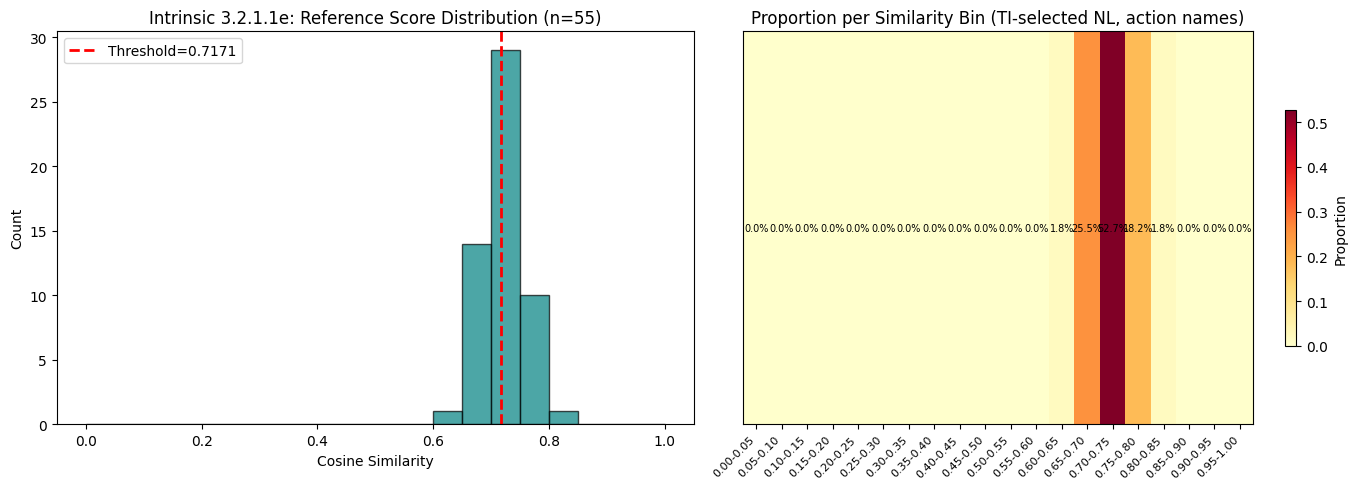

In [128]:
# --- Visualize intrinsic distribution for 3.3.1.1e (bge-base, TI-selected NL, action names) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.arange(0.0, 1.05, 0.05)
counts, _, patches = axes[0].hist(scores_intrinsic_e, bins=bins, edgecolor="black", alpha=0.7, color="teal")
axes[0].axvline(ci_low_ie, color="red", linestyle="--", linewidth=2, label=f"Threshold={ci_low_ie:.4f}")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Intrinsic 3.3.1.1e: Reference Score Distribution (n={len(scores_intrinsic_e)})")
axes[0].legend()

bin_labels = [f"{b:.2f}-{b+0.05:.2f}" for b in bins[:-1]]
proportions = counts / counts.sum()
heatmap_data = proportions.reshape(1, -1)
im = axes[1].imshow(heatmap_data, aspect="auto", cmap="YlOrRd", vmin=0)
axes[1].set_xticks(range(len(bin_labels)))
axes[1].set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=8)
axes[1].set_yticks([])
axes[1].set_title("Proportion per Similarity Bin (TI-selected NL, action names)")
for j in range(len(bin_labels)):
    axes[1].text(j, 0, f"{proportions[j]:.1%}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes[1], shrink=0.6, label="Proportion")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "intrinsic_threshold_distribution_ti_action_names.png"), dpi=150)
plt.show()

##### Spot-check similarities under each variant

In [33]:
# --- Spot-check similarities under each variant ---
spot_labels = sorted(set(r["label"] for r in emb_intrinsic_results))
spot_results = {
    "3.3.1.1":  {r["label"]: r["similarity"] for r in emb_intrinsic_results},
    "3.3.1.1b": {r["label"]: r["similarity"] for r in emb_intrinsic_results_b},
    "3.3.1.1e": {r["label"]: r["similarity"] for r in emb_intrinsic_results_e},
}

variants = [
    ("3.3.1.1",  "MiniLM, desc, full PDDL",              scores_intrinsic,    ci_low_i),
    ("3.3.1.1b", "bge-base, desc, full PDDL",             scores_intrinsic_b,  ci_low_ib),
    ("3.3.1.1e", "bge-base, TI-NL, action-names",         scores_intrinsic_e,  ci_low_ie),
]

print("--- Full Comparison (with spot-check) ---")
for key, desc, scores, thr in variants:
    print(f"  {key:11s} ({desc}):")
    print(f"    mean={scores.mean():.4f}  threshold={thr:.4f}")
    sims = spot_results[key]
    for label in spot_labels:
        sim = sims.get(label)
        if sim is None:
            continue
        status = "PASS" if sim >= thr else "BELOW"
        print(f"      {label:40s} sim={sim:.4f}  [{status}]")

NameError: name 'scores_intrinsic_e' is not defined

##### 3.3.1.2 LLM as an Expert: NL CVE Description vs PDDL Match

##### 3.3.1.2a TURE/FALSE
`llm_eval_intrinsic_binary`: generic classification using `llm_intrinsic_binary.jinja`(True/False)


Block 1: the function to prompt an LLM 

In [35]:
intrinsic_binary_template = prompt_env.get_template("llm_intrinsic_binary.jinja")

def llm_eval_intrinsic_binary(cve_id, description, domain, client, model, seed=42):
    """Binary True/False classification: does the PDDL match the CVE?"""
    prompt = intrinsic_binary_template.render(
        cve_id=cve_id, description=description, domain=domain
    )
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=512,
        seed=seed,
    )
    content = resp.choices[0].message.content
    tokens = {"prompt_tokens": resp.usage.prompt_tokens, "completion_tokens": resp.usage.completion_tokens, "total_tokens": resp.usage.total_tokens} if resp.usage else {}
    return content, tokens


 Block 2: call the function with the code and the specifications from the data set

In [141]:
# llm_intrinsic_results = []
# eval_set_path = Path(EVAL_SET_DIR)
# for cve_dir in sorted(eval_set_path.iterdir()):
#     if not cve_dir.is_dir():
#         continue
#     cve_id = cve_dir.name
#     description = cve_descriptions.get(cve_id)
#     if description is None:
#         print(f"SKIP {cve_id}: no description in target_pool.json")
#         continue
#     for config_dir in sorted(cve_dir.iterdir()):
#         if not config_dir.is_dir():
#             continue
#         domain_file = config_dir / DOMAIN_FILE
#         problem_file = config_dir / PROBLEM_FILE
#         if not domain_file.exists():
#             continue
#         domain = domain_file.read_text(encoding='utf-8').strip()
#         problem = problem_file.read_text(encoding='utf-8').strip() if problem_file.exists() else ''
#         response = llm_eval_intrinsic(description, domain, problem, llm)
#         llm_intrinsic_results.append({
#             'cve_id': cve_id,
#             'config': config_dir.name,
#             'llm_response': response,
#         })
#         print(f"{cve_id}/{config_dir.name}  response: {response}")

Because waiting more than 200ms didn’t work, add the free Qwen model to quickly validate the pipeline.

In [36]:

nvidia = OpenAI(
    api_key=os.getenv("NVIDIA_API_KEY"),
    base_url="https://integrate.api.nvidia.com/v1",
    timeout=120.0,
)
NVIDIA_MODEL = "meta/llama-3.3-70b-instruct"

llm_intrinsic_binary_results = []
# eval_set_path = Path(EVAL_SET_DIR)
# for cve_dir in sorted(eval_set_path.iterdir()):
#     if not cve_dir.is_dir():
#         continue
#     cve_id = cve_dir.name
#     description = cve_descriptions.get(cve_id)
#     if description is None:
#         print(f"SKIP {cve_id}: no description in target_pool.json")
#         continue
#     for config_dir in sorted(cve_dir.iterdir()):
#         if not config_dir.is_dir():
#             continue
#         domain_file = config_dir / DOMAIN_FILE
#         if not domain_file.exists():
#             continue
#         domain = domain_file.read_text(encoding="utf-8").strip()
#         response = llm_eval_intrinsic_binary(cve_id, description, domain, nvidia, NVIDIA_MODEL, seed=SEED)
#         result = {"cve_id": cve_id, "config": config_dir.name, "llm_response": response}
#         llm_intrinsic_binary_results.append(result)
#         (config_dir / "llm_intrinsic_binary.json").write_text(json.dumps(result, indent=2), encoding="utf-8")
        # Parse label from response
#         try:
#             text = response.strip()
#             if text.startswith("```"): text = text.split("\n", 1)[1].rsplit("```", 1)[0]
#             label = json.loads(text).get("label", "?")
#         except Exception:
#             label = "?"
#         print(f"{cve_id}/{config_dir.name:30s} | {label}")


t_start_llm_bin = time.time()
total_tokens_bin = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
# ── LLM intrinsic binary on reference data ──
llm_intrinsic_binary_results = []
for entry in dataset:
    for ap in entry["attack_paths"]:
        response, tokens = llm_eval_intrinsic_binary(entry["cve_id"], entry["description"], ap["domain"], nvidia, NVIDIA_MODEL, seed=SEED)
        for k in total_tokens_bin: total_tokens_bin[k] += tokens.get(k, 0)
        result = {"cve_id": entry["cve_id"], "config": ap["ap_id"], "llm_response": response, "tokens": tokens}
        llm_intrinsic_binary_results.append(result)
        try:
            text = response.strip()
            if text.startswith("```"): text = text.split("\n", 1)[1].rsplit("```", 1)[0]
            label = json.loads(text).get("label", "?")
        except Exception:
            label = "?"
        print(f"{entry['cve_id']}/{ap['ap_id']:30s} | {label}")

t_elapsed_llm_bin = time.time() - t_start_llm_bin

save_dir = os.path.join(RESULTS_BASE, "semantic", "intrinsic", "llm-as-experts")
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, f"results_binary_{NVIDIA_MODEL.replace('/', '_')}.json"), "w") as f:
    json.dump({"model": NVIDIA_MODEL, "results": llm_intrinsic_binary_results}, f, indent=2)

with open(os.path.join(save_dir, f"metadata_binary_{NVIDIA_MODEL.replace('/', '_')}.json"), "w") as f:
    json.dump({
        "time_seconds": t_elapsed_llm_bin,
        "model": NVIDIA_MODEL,
        "n_domains": len(llm_intrinsic_binary_results),
        "total_tokens": total_tokens_bin,
        "device_info": "API (nvidia)",
    }, f, indent=2)

print(f"\nTime: {t_elapsed_llm_bin:.2f}s, Tokens: {total_tokens_bin}")


CVE-2022-1471/AP1                            | True
CVE-2022-40149/AP1                            | True
CVE-2022-40149/AP2                            | True


KeyboardInterrupt: 

##### 3.3.1.2b Sophisticated Intrinsic Evaluation Prompt
`llm_eval_intrinsic_scored`: sophisticated evaluation using `llm_intrinsic.jinja` (10-criteria Likert 1-5)

Block 1: the function to prompt an LLM with the 10-criteria scoring rubric

In [37]:
intrinsic_scored_template = prompt_env.get_template("llm_intrinsic.jinja")

def llm_eval_intrinsic_scored(cve_id, description, domain, client, model, seed=42):
    """Sophisticated 10-criteria Likert 1-5 evaluation."""
    prompt = intrinsic_scored_template.render(
        cve_id=cve_id, description=description, domain=domain
    )
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=4096,
        seed=seed,
    )
    content = resp.choices[0].message.content
    tokens = {"prompt_tokens": resp.usage.prompt_tokens, "completion_tokens": resp.usage.completion_tokens, "total_tokens": resp.usage.total_tokens} if resp.usage else {}
    return content, tokens

Block 2: evaluation result parser and formatter

In [38]:
def parse_scored_response(response_text):
    """Parse LLM scored response JSON, extract scores."""
    try:
        # Strip markdown fences if present
        text = response_text.strip()
        if text.startswith("```"):
            text = text.split("\n", 1)[1]
            text = text.rsplit("```", 1)[0]
        data = json.loads(text)
        return data
    except Exception:
        return None

def summarize_intrinsic_scored(result):
    """Extract one-line summary from intrinsic scored result."""
    data = parse_scored_response(result["llm_response"])
    if data is None:
        return f"{result['cve_id']}/{result['config']}  PARSE_ERROR"
    # For action-level, compute mean from actions array
    actions = data.get("actions", [])
    action_scores = {}
    for key in ["F1", "F2", "A1", "A2"]:
        vals = [a[key] for a in actions if key in a]
        if vals:
            action_scores[key] = sum(vals) / len(vals)
    # Plan/CVE level
    plan_cve = {k: data.get(k) for k in ["C1","C2","C3","V1","V2","V3"] if k in data}
    all_scores = list(action_scores.values()) + [v for v in plan_cve.values() if v is not None]
    avg = sum(all_scores) / len(all_scores) if all_scores else 0
    n_actions = len(actions)
    f1 = f"{action_scores.get('F1', 0):.1f}"
    f2 = f"{action_scores.get('F2', 0):.1f}"
    a1 = f"{action_scores.get('A1', 0):.1f}"
    a2 = f"{action_scores.get('A2', 0):.1f}"
    c1 = plan_cve.get("C1", "?")
    c2 = plan_cve.get("C2", "?")
    c3 = plan_cve.get("C3", "?")
    v1 = plan_cve.get("V1", "?")
    v2 = plan_cve.get("V2", "?")
    v3 = plan_cve.get("V3", "?")
    return f"{result['cve_id']}/{result['config']:30s} | {n_actions:2d} | {f1:>4s} | {f2:>4s} | {a1:>4s} | {a2:>4s} | {c1} | {c2} | {c3} | {v1} | {v2} | {v3} | {avg:.2f}"

def summarize_extrinsic_scored(result):
    """Extract one-line summary from extrinsic scored result."""
    data = parse_scored_response(result["llm_response"])
    if data is None:
        return f"{result['cve_id']}/{result['generated']} vs {result['reference']}  PARSE_ERROR"
    actions = data.get("actions", [])
    action_scores = {}
    for key in ["F1", "F2", "A1", "A2"]:
        vals = [a[key] for a in actions if key in a]
        if vals:
            action_scores[key] = sum(vals) / len(vals)
    plan_cve_ref = {k: data.get(k) for k in ["C1","C2","C3","V1","V2","V3","R1","R2","R3","R4"] if k in data}
    all_scores = list(action_scores.values()) + [v for v in plan_cve_ref.values() if v is not None]
    avg = sum(all_scores) / len(all_scores) if all_scores else 0
    n_actions = len(actions)
    f1 = f"{action_scores.get('F1', 0):.1f}"
    f2 = f"{action_scores.get('F2', 0):.1f}"
    a1 = f"{action_scores.get('A1', 0):.1f}"
    a2 = f"{action_scores.get('A2', 0):.1f}"
    c1 = plan_cve_ref.get("C1", "?")
    c2 = plan_cve_ref.get("C2", "?")
    c3 = plan_cve_ref.get("C3", "?")
    v1 = plan_cve_ref.get("V1", "?")
    v2 = plan_cve_ref.get("V2", "?")
    v3 = plan_cve_ref.get("V3", "?")
    r1 = plan_cve_ref.get("R1", "?")
    r2 = plan_cve_ref.get("R2", "?")
    r3 = plan_cve_ref.get("R3", "?")
    r4 = plan_cve_ref.get("R4", "?")
    return f"{result['cve_id']}/{result['generated']:30s} vs {result['reference']} | {n_actions:2d} | {f1:>4s} | {f2:>4s} | {a1:>4s} | {a2:>4s} | {c1} | {c2} | {c3} | {v1} | {v2} | {v3} | {r1} | {r2} | {r3} | {r4} | {avg:.2f}"


Block 3: call the function with the code and the specifications from the data set

In [39]:
# NVIDIA_model-qwen-max
llm_intrinsic_scored_results = []
# eval_set_path = Path(EVAL_SET_DIR)
# print("Domain".ljust(45) + " | #A | F1 | F2 | A1 | A2 | C1 | C2 | C3 | V1 | V2 | V3 | Avg")
# print("-" * 120)
# for cve_dir in sorted(eval_set_path.iterdir()):
#     if not cve_dir.is_dir():
#         continue
#     cve_id = cve_dir.name
#     description = cve_descriptions.get(cve_id)
#     if description is None:
#         print(f"SKIP {cve_id}: no description in target_pool.json")
#         continue
#     for config_dir in sorted(cve_dir.iterdir()):
#         if not config_dir.is_dir():
#             continue
#         domain_file = config_dir / DOMAIN_FILE
#         if not domain_file.exists():
#             continue
#         domain = domain_file.read_text(encoding="utf-8").strip()
#         response = llm_eval_intrinsic_scored(cve_id, description, domain, nvidia, NVIDIA_MODEL, seed=SEED)
#         result = {"cve_id": cve_id, "config": config_dir.name, "llm_response": response}
#         llm_intrinsic_scored_results.append(result)
#         (config_dir / "llm_intrinsic_scored.json").write_text(json.dumps(result, indent=2), encoding="utf-8")
#         print(summarize_intrinsic_scored(result))

t_start_llm_scored = time.time()
total_tokens_scored = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
# ── LLM intrinsic scored on reference data (nvidia) ──
llm_intrinsic_scored_results = []
for entry in dataset:
    for ap in entry["attack_paths"]:
        response, tokens = llm_eval_intrinsic_scored(entry["cve_id"], entry["description"], ap["domain"], nvidia, NVIDIA_MODEL, seed=SEED)
        for k in total_tokens_scored: total_tokens_scored[k] += tokens.get(k, 0)
        result = {"cve_id": entry["cve_id"], "config": ap["ap_id"], "llm_response": response, "tokens": tokens}
        llm_intrinsic_scored_results.append(result)
        print(summarize_intrinsic_scored(result))

t_elapsed_llm_scored = time.time() - t_start_llm_scored

save_dir = os.path.join(RESULTS_BASE, "semantic", "intrinsic", "llm-as-experts")
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, f"results_scored_{NVIDIA_MODEL.replace('/', '_')}.json"), "w") as f:
    json.dump({"model": NVIDIA_MODEL, "results": llm_intrinsic_scored_results}, f, indent=2)

with open(os.path.join(save_dir, f"metadata_scored_{NVIDIA_MODEL.replace('/', '_')}.json"), "w") as f:
    json.dump({
        "time_seconds": t_elapsed_llm_scored,
        "model": NVIDIA_MODEL,
        "n_domains": len(llm_intrinsic_scored_results),
        "total_tokens": total_tokens_scored,
        "device_info": "API (nvidia)",
    }, f, indent=2)

print(f"\nTime: {t_elapsed_llm_scored:.2f}s, Tokens: {total_tokens_scored}")


KeyboardInterrupt: 

In [42]:
load_dotenv(override=True)  # override=True Force overwrite existing environment variables.  
key = os.getenv("OPENAI_API_KEY", "")                                                                                   
print(f"Key loaded: {key[:8]}...{key[-4:]}" if len(key) > 12 else "Key NOT found or too short") 

Key loaded: sk-proj-...z4wA


In [43]:
#gpt-4.1-mini
load_dotenv()


openai_client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    timeout=120.0,
)
GPT_MODEL = "gpt-4.1-mini"

# # ── eval_set (uncomment when ready) ──
# llm_intrinsic_scored_results_gpt = []
# eval_set_path = Path(EVAL_SET_DIR)
# print("Domain".ljust(45) + " | #A | F1 | F2 | A1 | A2 | C1 | C2 | C3 | V1 | V2 | V3 | Avg")
# print("-" * 120)
# for cve_dir in sorted(eval_set_path.iterdir()):
#     if not cve_dir.is_dir():
#         continue
#     cve_id = cve_dir.name
#     description = cve_descriptions.get(cve_id)
#     if description is None:
#         print(f"SKIP {cve_id}: no description in target_pool.json")
#         continue
#     for config_dir in sorted(cve_dir.iterdir()):
#         if not config_dir.is_dir():
#             continue
#         domain_file = config_dir / DOMAIN_FILE
#         if not domain_file.exists():
#             continue
#         domain = domain_file.read_text(encoding="utf-8").strip()
#         response = llm_eval_intrinsic_scored(cve_id, description, domain, openai_client, GPT_MODEL, seed=SEED)
#         result = {"cve_id": cve_id, "config": config_dir.name, "llm_response": response}
#         llm_intrinsic_scored_results_gpt.append(result)
#         (config_dir / "llm_intrinsic_scored_gpt.json").write_text(json.dumps(result, indent=2), encoding="utf-8")
#         print(summarize_intrinsic_scored(result))

t_start_llm_gpt = time.time()
total_tokens_gpt = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
# ── LLM intrinsic scored on reference data (GPT) ──
llm_intrinsic_scored_results_gpt = []
for entry in dataset:
    for ap in entry["attack_paths"]:
        response, tokens = llm_eval_intrinsic_scored(entry["cve_id"], entry["description"], ap["domain"], openai_client, GPT_MODEL, seed=SEED)
        for k in total_tokens_gpt: total_tokens_gpt[k] += tokens.get(k, 0)
        result = {"cve_id": entry["cve_id"], "config": ap["ap_id"], "llm_response": response, "tokens": tokens}
        llm_intrinsic_scored_results_gpt.append(result)
        print(summarize_intrinsic_scored(result))

t_elapsed_llm_gpt = time.time() - t_start_llm_gpt

save_dir = os.path.join(RESULTS_BASE, "semantic", "intrinsic", "llm-as-experts")
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, f"results_scored_{GPT_MODEL.replace('.', '_')}.json"), "w") as f:
    json.dump({"model": GPT_MODEL, "results": llm_intrinsic_scored_results_gpt}, f, indent=2)

with open(os.path.join(save_dir, f"metadata_scored_{GPT_MODEL.replace('.', '_')}.json"), "w") as f:
    json.dump({
        "time_seconds": t_elapsed_llm_gpt,
        "model": GPT_MODEL,
        "n_domains": len(llm_intrinsic_scored_results_gpt),
        "total_tokens": total_tokens_gpt,
        "device_info": "API (OpenAI)",
    }, f, indent=2)

print(f"\nTime: {t_elapsed_llm_gpt:.2f}s, Tokens: {total_tokens_gpt}")


CVE-2022-1471/AP1                            | 14 |  5.0 |  5.0 |  5.0 |  5.0 | 5 | 5 | 5 | 5 | 5 | 5 | 5.00
CVE-2022-40149/AP1                            |  9 |  5.0 |  4.9 |  4.9 |  5.0 | 5 | 5 | 5 | 5 | 5 | 5 | 4.98


KeyboardInterrupt: 

Why the current evaluation prompt:
- Some LLM models, such as Qwen are poor in distingushing the good PDDL AP domain (and handling longer context), just for validating
  - change to a stronger model
     - gpt-4.1 (and latest versions), claude sonnet, opus, etc. is much better in diistingushing.
  - provide few-shot calibration: one good example and one worser example

Question:
- whether delete problem.pddl, only provide core i.e., `(:action name`, `(:parameters)`, `(:preconditions)`,  `(:effects)` ？
    - problem.pddl, `(:predicats)` `(:types)` `(:constants)` `(:functions)` just for pddl syntax, and sovalbility, which has been validated by metric-ff and enhsp.
    - the paper ``plan in the dark'' just focuses on action
- whether use the hard negative to validate whether the LLM can be the expert to evaluate?
- whether prepare 3 different llm as experts? 
   - then compute **Krippendorff's alpha** (ordinal) for each item and each construct.
    - Acceptable threshold: α ≥ 0.667 (tentative agreement); α ≥ 0.800 (good agreement)
    - If α < 0.667 for any item, conduct a reconciliation session and re-evaluate the item's operationalization.

#### 3.3.2 Extrinsic

##### 3.3.2.1a Embedding: reference PDDL vs generated PDDL Similarity

Block 1: the function to compute the embedding similarity between two blocks of PDDL code (domain + problem)

In [44]:
def embedding_similarity_extrinsic(pddl_texts_generated, pddl_texts_reference, model):
    """Cosine similarity matrix between generated and reference PDDL codes.
    Args:
        pddl_texts_generated: list of generated PDDL domain strings
        pddl_texts_reference: list of reference PDDL domain strings
        model: SentenceTransformer model
    Returns:
        numpy array of shape (len(generated), len(reference))
    """
    E_generated = model.encode(
        pddl_texts_generated,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    E_reference = model.encode(
        pddl_texts_reference,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    S = E_generated @ E_reference.T
    return S.float().cpu().numpy()

Block 2: call the function with the code from the data set

In [45]:
ref_by_cve = {entry['cve_id']: entry['attack_paths'] for entry in dataset}

emb_extrinsic_results = []
# eval_set_path = Path(EVAL_SET_DIR)
# for cve_dir in sorted(eval_set_path.iterdir()):
#     if not cve_dir.is_dir():
#         continue
#     cve_id = cve_dir.name
#     ref_aps = ref_by_cve.get(cve_id, [])
#     if not ref_aps:
#         print(f"SKIP {cve_id}: no reference APs in dataset")
#         continue

    # Collect all generated PDDL texts for this CVE
#     gen_texts = []
#     gen_labels = []
#     for config_dir in sorted(cve_dir.iterdir()):
#         if not config_dir.is_dir():
#             continue
#         domain_file = config_dir / DOMAIN_FILE
#         if not domain_file.exists():
#             continue
#         domain = domain_file.read_text(encoding='utf-8').strip()
#         gen_texts.append(domain)
#         gen_labels.append(config_dir.name)

#     if not gen_texts:
#         continue

    # Collect all reference PDDL texts for this CVE
#     ref_texts = [ap['domain'] for ap in ref_aps]
#     ref_labels = [ap['ap_id'] for ap in ref_aps]

    # Batch compute similarity matrix: (num_generated x num_reference)
#     sim_matrix = embedding_similarity_extrinsic(gen_texts, ref_texts, embedding_model)

#     for i, gen_label in enumerate(gen_labels):
#         for j, ref_label in enumerate(ref_labels):
#             sim = float(sim_matrix[i, j])
#             emb_extrinsic_results.append({
#                 'cve_id': cve_id,
#                 'generated': gen_label,
#                 'reference': ref_label,
#                 'similarity': sim,
#             })
#             print(f"{cve_id}/{gen_label} vs {ref_label}  similarity: {sim:.4f}")

t_start_ext_emb = time.time()
# ── Extrinsic embedding on reference data (Model A) ──
emb_extrinsic_results = []
for entry in dataset:
    ref_aps = entry["attack_paths"]
    if len(ref_aps) < 2:
        continue
    texts = [ap["domain"] for ap in ref_aps]
    E = embedding_model.encode(texts, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    S = (E @ E.T).float().cpu().numpy()
    for i in range(len(ref_aps)):
        for j in range(i+1, len(ref_aps)):
            sim = float(S[i, j])
            emb_extrinsic_results.append({
                "cve_id": entry["cve_id"],
                "generated": ref_aps[i]["ap_id"],
                "reference": ref_aps[j]["ap_id"],
                "similarity": sim,
            })
            print(f"{entry['cve_id']}/{ref_aps[i]['ap_id']} vs {ref_aps[j]['ap_id']}  similarity: {sim:.4f}")

t_elapsed_ext_emb = time.time() - t_start_ext_emb

save_dir = os.path.join(RESULTS_BASE, "semantic", "extrinsic", "similarity")
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, f"results_{EMBEDDING_MODEL_NAME.replace('/', '_')}.json"), "w") as f:
    json.dump({"model": EMBEDDING_MODEL_NAME, "results": emb_extrinsic_results}, f, indent=2)

with open(os.path.join(save_dir, f"metadata_{EMBEDDING_MODEL_NAME.replace('/', '_')}.json"), "w") as f:
    json.dump({
        "time_seconds": t_elapsed_ext_emb,
        "model": EMBEDDING_MODEL_NAME,
        "n_pairs": len(emb_extrinsic_results),
        "device_info": get_device_info(),
    }, f, indent=2)

print(f"\nTime: {t_elapsed_ext_emb:.2f}s")


CVE-2022-40149/AP1 vs AP2  similarity: 1.0000
CVE-2022-40150/AP1 vs AP2  similarity: 1.0000
CVE-2023-2976/AP1 vs AP2  similarity: 0.9975
CVE-2023-2976/AP1 vs AP3  similarity: 0.9877
CVE-2023-2976/AP2 vs AP3  similarity: 0.9881
CVE-2023-33202/AP1 vs AP2  similarity: 0.9853
CVE-2023-33202/AP1 vs AP3  similarity: 0.9770
CVE-2023-33202/AP2 vs AP3  similarity: 0.9762
CVE-2023-46589/AP1 vs AP2  similarity: 0.9704
CVE-2023-46589/AP1 vs AP3  similarity: 1.0000
CVE-2023-46589/AP1 vs AP4  similarity: 0.9704
CVE-2023-46589/AP2 vs AP3  similarity: 0.9704
CVE-2023-46589/AP2 vs AP4  similarity: 1.0000
CVE-2023-46589/AP3 vs AP4  similarity: 0.9704
CVE-2024-12798/AP1 vs AP2  similarity: 0.9830
CVE-2024-12798/AP1 vs AP3  similarity: 0.9813
CVE-2024-12798/AP1 vs AP4  similarity: 0.9823
CVE-2024-12798/AP1 vs AP5  similarity: 0.9823
CVE-2024-12798/AP1 vs AP6  similarity: 0.9805
CVE-2024-12798/AP1 vs AP7  similarity: 0.9767
CVE-2024-12798/AP2 vs AP3  similarity: 0.9944
CVE-2024-12798/AP2 vs AP4  similarity

Block 3: Use bootstrapping to find the best threshold for the exntrinsic semantic similarity.

In [174]:
def collect_reference_scores_extrinsic(dataset, model):
    """Compute cosine similarities between reference APs of the same CVE.
    For CVEs with multiple APs, all intra-CVE pairs are included.
    For CVEs with a single AP, self-similarity (=1.0) is included."""
    scores = []
    for entry in dataset:
        aps = entry['attack_paths']
        if not aps:
            continue
        texts = [ap['domain'] for ap in aps]
        E = model.encode(texts, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
        S = (E @ E.T).float().cpu().numpy()
        n = len(texts)
        for i in range(n):
            for j in range(i, n):
                scores.append(S[i, j])
    return np.array(scores)


scores_extrinsic = collect_reference_scores_extrinsic(dataset, embedding_model)
ci_low_e, ci_high_e, boot_means_e = bootstrap_threshold(scores_extrinsic, seed=SEED)

print(f"Extrinsic threshold (model={EMBEDDING_MODEL_NAME}, n={len(scores_extrinsic)})")
print(f"  mean={scores_extrinsic.mean():.4f}  std={scores_extrinsic.std():.4f}  "
      f"min={scores_extrinsic.min():.4f}  max={scores_extrinsic.max():.4f}")
print(f"  95% CI of mean: [{ci_low_e:.4f}, {ci_high_e:.4f}]")
print(f"  Suggested threshold (CI lower bound): {ci_low_e:.4f}")

Extrinsic threshold (model=all-MiniLM-L6-v2, n=129)
  mean=0.9930  std=0.0101  min=0.9447  max=1.0000
  95% CI of mean: [0.9913, 0.9947]
  Suggested threshold (CI lower bound): 0.9913


Block 4: Extrinsic cross-validation, performance estimation, and corrected proportion
Same process as intrinsic Block 5 but for extrinsic (domain vs domain):
1. Build positive/negative pairs: 
  - 1：CVE PDDL AP vs the PDDL APs of the same CVE 
  - 0：CVE PDDL AP vs the PDDL APs of the different CVE  
2. CVE-level GroupKFold CV with bootstrap threshold
3. Out-of-fold predictions → classification report → TPR, FPR
4. Apply threshold to reference domains

In [46]:
# ── Step 1: Build extrinsic positive/negative pairs ──

def build_extrinsic_pairs(dataset, model):
    """
    Build (scores, labels, groups) for extrinsic embedding evaluation.
    Positive (1): same CVE, different APs (domain_i vs domain_j)
    Negative (0): different CVE (domain_i vs domain_j)
    Groups: assigned by CVE of first domain in pair
    """
    # Collect all (domain, cve_id) pairs
    all_entries = []
    for entry in dataset:
        for ap in entry["attack_paths"]:
            all_entries.append((ap["domain"], entry["cve_id"], ap["ap_id"]))

    domains = [p[0] for p in all_entries]
    cve_ids = [p[1] for p in all_entries]

    # Batch encode
    E = model.encode(domains, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    sim_matrix = (E @ E.T).float().cpu().numpy()

    scores, labels, groups = [], [], []
    n = len(all_entries)
    for i in range(n):
        for j in range(i+1, n):  # upper triangle only, symmetric
            sim = float(sim_matrix[i, j])
            label = 1 if cve_ids[i] == cve_ids[j] else 0
            scores.append(sim)
            labels.append(label)
            groups.append(cve_ids[i])  # group by first domain's CVE

    return np.array(scores), np.array(labels), np.array(groups)


ext_scores_a, ext_labels_a, ext_groups_a = build_extrinsic_pairs(dataset, embedding_model)
print(f"Extrinsic Embedding Model: {EMBEDDING_MODEL_NAME}")
print(f"  Positive pairs: {ext_labels_a.sum()}, Negative pairs: {(ext_labels_a == 0).sum()}")
print(f"  Groups (CVEs): {len(np.unique(ext_groups_a))}")


Extrinsic Embedding Model: all-MiniLM-L6-v2
  Positive pairs: 74, Negative pairs: 1411
  Groups (CVEs): 21


In [47]:
# ── Step 2: Extrinsic CV calibration ──

ext_cv_threshold_a, ext_cv_fold_thr_a, ext_cv_pred_a, ext_cv_true_a = run_calibration(
    ext_scores_a, ext_labels_a, ext_groups_a)
print(f"\nMedian threshold: {ext_cv_threshold_a:.4f}")
print("Fold thresholds:", [f"{t:.4f}" for t in ext_cv_fold_thr_a])


  Fold 1: threshold=0.9621, val CVEs=['CVE-2022-1471', 'CVE-2024-12798', 'CVE-2024-38809', 'CVE-2025-24813']
  Fold 2: threshold=0.9744, val CVEs=['CVE-2023-44487', 'CVE-2023-46589', 'CVE-2024-22262', 'CVE-2024-38820', 'CVE-2024-47072']
  Fold 3: threshold=0.9383, val CVEs=['CVE-2022-40150', 'CVE-2023-2976', 'CVE-2023-6378', 'CVE-2024-38816']
  Fold 4: threshold=0.9621, val CVEs=['CVE-2024-22243', 'CVE-2024-22259', 'CVE-2024-34447', 'CVE-2024-38286']
  Fold 5: threshold=0.9621, val CVEs=['CVE-2022-40149', 'CVE-2023-33202', 'CVE-2023-34055', 'CVE-2025-22228']

Median threshold: 0.9621
Fold thresholds: ['0.9621', '0.9744', '0.9383', '0.9621', '0.9621']


In [48]:
# ── Step 3: Extrinsic performance report ──

print(f"Extrinsic Embedding Model ({EMBEDDING_MODEL_NAME})")
print(classification_report(ext_cv_true_a, ext_cv_pred_a, zero_division=0))

ext_row_a = report_row(ext_cv_true_a, ext_cv_pred_a,
                      metric="embedding", model=EMBEDDING_MODEL_NAME,
                      mode="extrinsic", threshold=ext_cv_threshold_a)
print(f"TPR = {ext_row_a['tpr']:.4f}  FPR = {ext_row_a['fpr']:.4f}")


Extrinsic Embedding Model (all-MiniLM-L6-v2)
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1411
           1       0.45      0.92      0.61        74

    accuracy                           0.94      1485
   macro avg       0.72      0.93      0.79      1485
weighted avg       0.97      0.94      0.95      1485

TPR = 0.9189  FPR = 0.0581


In [49]:
# ── Step 4: Apply extrinsic threshold to reference domains ──

# For extrinsic, apply threshold to all intra-CVE AP pairs
ext_ref_results_a = []
for entry in dataset:
    ref_aps = entry["attack_paths"]
    if len(ref_aps) < 2:
        continue
    texts = [ap["domain"] for ap in ref_aps]
    E = embedding_model.encode(texts, convert_to_tensor=True, normalize_embeddings=True, show_progress_bar=False)
    S = (E @ E.T).float().cpu().numpy()
    for i in range(len(ref_aps)):
        for j in range(i+1, len(ref_aps)):
            sim = float(S[i, j])
            pred = 1 if sim >= ext_cv_threshold_a else 0
            label = f"{entry['cve_id']}/{ref_aps[i]['ap_id']} vs {ref_aps[j]['ap_id']}"
            ext_ref_results_a.append({"label": label, "similarity": sim, "prediction": pred})
            print(f"  {label:45s} prediction: {pred} (similarity: {sim:.4f})")

ext_ref_ppv_a = sum(r["prediction"] for r in ext_ref_results_a) / len(ext_ref_results_a) if ext_ref_results_a else 0
print(f"  Extrinsic Reference PPV: {ext_ref_ppv_a:.4f} ({sum(r['prediction'] for r in ext_ref_results_a)}/{len(ext_ref_results_a)} predicted positive)")

# Save
ext_save_data = {
    "metric": "embedding", "model": EMBEDDING_MODEL_NAME, "mode": "extrinsic",
    "median_threshold": ext_cv_threshold_a, "fold_thresholds": ext_cv_fold_thr_a,
    "tpr": ext_row_a["tpr"], "fpr": ext_row_a["fpr"],
    "classification_report": classification_report(ext_cv_true_a, ext_cv_pred_a, output_dict=True, zero_division=0),
    "n_positive_pairs": int(ext_labels_a.sum()), "n_negative_pairs": int((ext_labels_a == 0).sum()),
    "ref_ppv": ext_ref_ppv_a, "reference_predictions": ext_ref_results_a,
}
ext_save_path = Path(EVAL_SET_DIR) / f"cv_calibration_extrinsic_{EMBEDDING_MODEL_NAME.replace('/', '_')}.json"
ext_save_path.write_text(json.dumps(ext_save_data, indent=2), encoding="utf-8")
print(f"\nSaved: {ext_save_path}")

calibration_embedding_rows.append({
    "model": EMBEDDING_MODEL_NAME, "mode": "extrinsic", "threshold": ext_cv_threshold_a,
    "tpr": ext_row_a["tpr"], "fpr": ext_row_a["fpr"],
    "1__precision": ext_row_a.get("1__precision", float("nan")),
    "1__recall": ext_row_a.get("1__recall", float("nan")),
    "1__f1-score": ext_row_a.get("1__f1-score", float("nan")),
    "accuracy": ext_row_a.get("accuracy", float("nan")),
    "ref_ppv": ext_ref_ppv_a,
    "n_positive": int(ext_labels_a.sum()), "n_negative": int((ext_labels_a == 0).sum()),
})


  CVE-2022-40149/AP1 vs AP2                     prediction: 1 (similarity: 1.0000)
  CVE-2022-40150/AP1 vs AP2                     prediction: 1 (similarity: 1.0000)
  CVE-2023-2976/AP1 vs AP2                      prediction: 1 (similarity: 0.9975)
  CVE-2023-2976/AP1 vs AP3                      prediction: 1 (similarity: 0.9877)
  CVE-2023-2976/AP2 vs AP3                      prediction: 1 (similarity: 0.9881)
  CVE-2023-33202/AP1 vs AP2                     prediction: 1 (similarity: 0.9853)
  CVE-2023-33202/AP1 vs AP3                     prediction: 1 (similarity: 0.9770)
  CVE-2023-33202/AP2 vs AP3                     prediction: 1 (similarity: 0.9762)
  CVE-2023-46589/AP1 vs AP2                     prediction: 1 (similarity: 0.9704)
  CVE-2023-46589/AP1 vs AP3                     prediction: 1 (similarity: 1.0000)
  CVE-2023-46589/AP1 vs AP4                     prediction: 1 (similarity: 0.9704)
  CVE-2023-46589/AP2 vs AP3                     prediction: 1 (similarity: 0.9704)
  CV

##### k4block/CodeBLEU

- Couldn't be integrated without effort, skip.
  - reason: 
    - CodeBLEU requires a **tree-sitter grammar** for the target language. 
    - CodeBLEU only supports 10 languages (Java, Python, C, etc.), with **no custom grammar interface**. 
    - No exisiting PDDL `tree-sitter` grammar, no [`tree-sitter-pddl`](https://github.com/tree-sitter/tree-sitter/wiki/List-of-parsers?utm_source=chatgpt.com)
- Other implementations: [Microsoft CodeXGLUE](https://github.com/microsoft/codexglue?utm_source=chatgpt.com), [Microsoft CodeBERT/CodeReviewer](https://github.com/microsoft/CodeBERT/blob/master/CodeReviewer/code/evaluator/CodeBLEU/calc_code_bleu.py?utm_source=chatgpt.com), also **No**.

##### 3.3.2.2 LLM as an Expert — Reference PDDL vs Candidate PDDL Match

##### 3.3.2.2a TRUE/FALSE
`llm_eval_extrinsic_binary`: generic classification using `llm_extrinsic_binary.jinja`

Block 1: the function to prompt an LLM with a binary True/False evaluation

In [51]:
extrinsic_binary_template = prompt_env.get_template("llm_extrinsic_binary.jinja")

def llm_eval_extrinsic_binary(cve_id, description, domain_reference, domain_generated, client, model, seed=42):
    """Binary True/False: does the candidate match the reference?"""
    prompt = extrinsic_binary_template.render(
        cve_id=cve_id, description=description,
        domain_reference=domain_reference,
        domain_generated=domain_generated,
    )
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=512,
        seed=seed,
    )
    content = resp.choices[0].message.content
    tokens = {"prompt_tokens": resp.usage.prompt_tokens, "completion_tokens": resp.usage.completion_tokens, "total_tokens": resp.usage.total_tokens} if resp.usage else {}
    return content, tokens


Block 2: call the function with the code and the specifications from the data set

In [52]:
llm_extrinsic_binary_results = []
# eval_set_path = Path(EVAL_SET_DIR)
# for cve_dir in sorted(eval_set_path.iterdir()):
#     if not cve_dir.is_dir():
#         continue
#     cve_id = cve_dir.name
#     description = cve_descriptions.get(cve_id)
#     ref_aps = ref_by_cve.get(cve_id, [])
#     if description is None or not ref_aps:
#         print(f"SKIP {cve_id}: no description or no reference APs")
#         continue
#     for config_dir in sorted(cve_dir.iterdir()):
#         if not config_dir.is_dir():
#             continue
#         domain_file = config_dir / DOMAIN_FILE
#         if not domain_file.exists():
#             continue
#         domain_generated = domain_file.read_text(encoding="utf-8").strip()
#         for ref_ap in ref_aps:
#             response = llm_eval_extrinsic_binary(
#                 cve_id, description, ref_ap["domain"],
#                 domain_generated, nvidia, NVIDIA_MODEL, seed=SEED
#             )
#             result = {
#                 "cve_id": cve_id, "generated": config_dir.name,
#                 "reference": ref_ap["ap_id"], "llm_response": response,
#             }
#             llm_extrinsic_binary_results.append(result)
#             save_name = f"llm_extrinsic_binary_vs_{ref_ap['ap_id']}.json"
#             (config_dir / save_name).write_text(json.dumps(result, indent=2), encoding="utf-8")
#             try:
#                 text = response.strip()
#                 if text.startswith("```"): text = text.split("\n", 1)[1].rsplit("```", 1)[0]
#                 label = json.loads(text).get("label", "?")
#             except Exception:
#                 label = "?"
#             print(f"{cve_id}/{config_dir.name:30s} vs {ref_ap['ap_id']} | {label}")


t_start_ext_bin = time.time()
total_tokens_ext_bin = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
# ── LLM extrinsic binary on reference data ──
llm_extrinsic_binary_results = []
for entry in dataset:
    ref_aps = entry["attack_paths"]
    if len(ref_aps) < 2:
        continue
    for i, ap_gen in enumerate(ref_aps):
        for j, ap_ref in enumerate(ref_aps):
            if i == j:
                continue
            response, tokens = llm_eval_extrinsic_binary(
                entry["cve_id"], entry["description"], ap_ref["domain"],
                ap_gen["domain"], nvidia, NVIDIA_MODEL, seed=SEED)
            for k in total_tokens_ext_bin: total_tokens_ext_bin[k] += tokens.get(k, 0)
            result = {
                "cve_id": entry["cve_id"], "generated": ap_gen["ap_id"],
                "reference": ap_ref["ap_id"], "llm_response": response, "tokens": tokens,
            }
            llm_extrinsic_binary_results.append(result)
            try:
                text = response.strip()
                if text.startswith("```"): text = text.split("\n", 1)[1].rsplit("```", 1)[0]
                label = json.loads(text).get("label", "?")
            except Exception:
                label = "?"
            print(f"{entry['cve_id']}/{ap_gen['ap_id']:20s} vs {ap_ref['ap_id']} | {label}")

t_elapsed_ext_bin = time.time() - t_start_ext_bin

save_dir = os.path.join(RESULTS_BASE, "semantic", "extrinsic", "llm-as-experts")
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, f"results_binary_{NVIDIA_MODEL.replace('/', '_')}.json"), "w") as f:
    json.dump({"model": NVIDIA_MODEL, "results": llm_extrinsic_binary_results}, f, indent=2)

with open(os.path.join(save_dir, f"metadata_binary_{NVIDIA_MODEL.replace('/', '_')}.json"), "w") as f:
    json.dump({
        "time_seconds": t_elapsed_ext_bin,
        "model": NVIDIA_MODEL,
        "n_pairs": len(llm_extrinsic_binary_results),
        "total_tokens": total_tokens_ext_bin,
        "device_info": "API (nvidia)",
    }, f, indent=2)

print(f"\nTime: {t_elapsed_ext_bin:.2f}s, Tokens: {total_tokens_ext_bin}")


CVE-2022-40149/AP1                  vs AP2 | False


KeyboardInterrupt: 

##### 3.3.2.2b Sophisticated Extrinsic Evaluation
`llm_eval_extrinsic_scored`: sophisticated evaluation using `llm_extrinsic.jinja` (13-criteria Likert 1-5)

Block 1: the function to prompt an LLM with the 13-criteria scoring rubric

In [53]:
extrinsic_scored_template = prompt_env.get_template("llm_extrinsic.jinja")

def llm_eval_extrinsic_scored(cve_id, description, domain_reference, domain_generated, client, model, seed=42):
    """Sophisticated 13-criteria Likert 1-5 evaluation (10 semantic + 3 reference-comparison)."""
    prompt = extrinsic_scored_template.render(
        cve_id=cve_id, description=description,
        domain_reference=domain_reference,
        domain_generated=domain_generated,
    )
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=4096,
        seed=seed,
    )
    content = resp.choices[0].message.content
    tokens = {"prompt_tokens": resp.usage.prompt_tokens, "completion_tokens": resp.usage.completion_tokens, "total_tokens": resp.usage.total_tokens} if resp.usage else {}
    return content, tokens


Block 2: call the function with the code and the specifications from the data set

In [54]:
llm_extrinsic_scored_results = []
# eval_set_path = Path(EVAL_SET_DIR)
# print("Domain".ljust(45) + " | Ref  | #A | F1 | F2 | A1 | A2 | C1 | C2 | C3 | V1 | V2 | V3 | R1 | R2 | R3 | R4 | Avg")
# print("-" * 150)
# for cve_dir in sorted(eval_set_path.iterdir()):
#     if not cve_dir.is_dir():
#         continue
#     cve_id = cve_dir.name
#     description = cve_descriptions.get(cve_id)
#     ref_aps = ref_by_cve.get(cve_id, [])
#     if description is None or not ref_aps:
#         print(f"SKIP {cve_id}: no description or no reference APs")
#         continue
#     for config_dir in sorted(cve_dir.iterdir()):
#         if not config_dir.is_dir():
#             continue
#         domain_file = config_dir / DOMAIN_FILE
#         if not domain_file.exists():
#             continue
#         domain_generated = domain_file.read_text(encoding="utf-8").strip()
#         for ref_ap in ref_aps:
#             response = llm_eval_extrinsic_scored(
#                 cve_id, description, ref_ap["domain"],
#                 domain_generated, nvidia, NVIDIA_MODEL, seed=SEED
#             )
#             result = {
#                 "cve_id": cve_id, "generated": config_dir.name,
#                 "reference": ref_ap["ap_id"], "llm_response": response,
#             }
#             llm_extrinsic_scored_results.append(result)
#             save_name = f"llm_extrinsic_scored_vs_{ref_ap['ap_id']}.json"
#             (config_dir / save_name).write_text(json.dumps(result, indent=2), encoding="utf-8")
#             print(summarize_extrinsic_scored(result))


t_start_ext_scored = time.time()
total_tokens_ext_scored = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
# ── LLM extrinsic scored on reference data (nvidia) ──
llm_extrinsic_scored_results = []
for entry in dataset:
    ref_aps = entry["attack_paths"]
    if len(ref_aps) < 2:
        continue
    for i, ap_gen in enumerate(ref_aps):
        for j, ap_ref in enumerate(ref_aps):
            if i == j:
                continue
            response, tokens = llm_eval_extrinsic_scored(
                entry["cve_id"], entry["description"], ap_ref["domain"],
                ap_gen["domain"], nvidia, NVIDIA_MODEL, seed=SEED)
            for k in total_tokens_ext_scored: total_tokens_ext_scored[k] += tokens.get(k, 0)
            result = {
                "cve_id": entry["cve_id"], "generated": ap_gen["ap_id"],
                "reference": ap_ref["ap_id"], "llm_response": response, "tokens": tokens,
            }
            llm_extrinsic_scored_results.append(result)
            print(summarize_extrinsic_scored(result))

t_elapsed_ext_scored = time.time() - t_start_ext_scored

save_dir = os.path.join(RESULTS_BASE, "semantic", "extrinsic", "llm-as-experts")
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, f"results_scored_{NVIDIA_MODEL.replace('/', '_')}.json"), "w") as f:
    json.dump({"model": NVIDIA_MODEL, "results": llm_extrinsic_scored_results}, f, indent=2)

with open(os.path.join(save_dir, f"metadata_scored_{NVIDIA_MODEL.replace('/', '_')}.json"), "w") as f:
    json.dump({
        "time_seconds": t_elapsed_ext_scored,
        "model": NVIDIA_MODEL,
        "n_pairs": len(llm_extrinsic_scored_results),
        "total_tokens": total_tokens_ext_scored,
        "device_info": "API (nvidia)",
    }, f, indent=2)

print(f"\nTime: {t_elapsed_ext_scored:.2f}s, Tokens: {total_tokens_ext_scored}")


KeyboardInterrupt: 

Block 3: call the function with GPT-4.1-mini (reuses `parse_scored_response` and `summarize_extrinsic_scored` from intrinsic section)

In [55]:
# # ── eval_set (uncomment when ready) ──
# from dotenv import load_dotenv
# load_dotenv(override=True)
# openai_client = OpenAI(
#     api_key=os.getenv("OPENAI_API_KEY"),
#     timeout=120.0,
# )
# GPT_MODEL = "gpt-4.1-mini"
# llm_extrinsic_scored_results_gpt = []
# eval_set_path = Path(EVAL_SET_DIR)
# ...

t_start_ext_gpt = time.time()
total_tokens_ext_gpt = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
# ── LLM extrinsic scored on reference data (GPT) ──
llm_extrinsic_scored_results_gpt = []
for entry in dataset:
    ref_aps = entry["attack_paths"]
    if len(ref_aps) < 2:
        continue
    for i, ap_gen in enumerate(ref_aps):
        for j, ap_ref in enumerate(ref_aps):
            if i == j:
                continue
            response, tokens = llm_eval_extrinsic_scored(
                entry["cve_id"], entry["description"], ap_ref["domain"],
                ap_gen["domain"], openai_client, GPT_MODEL, seed=SEED)
            for k in total_tokens_ext_gpt: total_tokens_ext_gpt[k] += tokens.get(k, 0)
            result = {
                "cve_id": entry["cve_id"], "generated": ap_gen["ap_id"],
                "reference": ap_ref["ap_id"], "llm_response": response, "tokens": tokens,
            }
            llm_extrinsic_scored_results_gpt.append(result)
            print(summarize_extrinsic_scored(result))

t_elapsed_ext_gpt = time.time() - t_start_ext_gpt

save_dir = os.path.join(RESULTS_BASE, "semantic", "extrinsic", "llm-as-experts")
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, f"results_scored_{GPT_MODEL.replace('.', '_')}.json"), "w") as f:
    json.dump({"model": GPT_MODEL, "results": llm_extrinsic_scored_results_gpt}, f, indent=2)

with open(os.path.join(save_dir, f"metadata_scored_{GPT_MODEL.replace('.', '_')}.json"), "w") as f:
    json.dump({
        "time_seconds": t_elapsed_ext_gpt,
        "model": GPT_MODEL,
        "n_pairs": len(llm_extrinsic_scored_results_gpt),
        "total_tokens": total_tokens_ext_gpt,
        "device_info": "API (OpenAI)",
    }, f, indent=2)

print(f"\nTime: {t_elapsed_ext_gpt:.2f}s, Tokens: {total_tokens_ext_gpt}")


CVE-2022-40149/AP1                            vs AP2 |  9 |  5.0 |  5.0 |  5.0 |  5.0 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | 5.00


KeyboardInterrupt: 